# Handwritten Digit Detection using CNN in PyTorch
### Classroom-ready Colab notebook

This notebook builds a **Convolutional Neural Network (CNN)** for **handwritten digit recognition** using the **MNIST** dataset.

It is designed to be:

- easy to understand
- beginner friendly
- ready to run in **Google Colab**
- full of explanations and visualizations

---

## What you will learn

By the end of this notebook, you will understand:

1. what the MNIST dataset is  
2. why CNNs are useful for image classification  
3. how to load image data in PyTorch  
4. how to define a simple CNN model  
5. how to train the model  
6. how to evaluate model performance  
7. how to test predictions on sample handwritten digits

## 1. Why do we need CNN for handwritten digit recognition?

A handwritten digit image is a grid of pixel values.  
For MNIST, each image is **28 × 28 pixels** and grayscale.

A normal fully connected neural network can learn from these pixels, but it does not naturally understand:

- nearby pixels form patterns
- edges, curves, and strokes are important
- the same digit can appear at slightly different positions

A **CNN (Convolutional Neural Network)** is better because it:

- learns **local patterns** such as edges and curves
- uses **filters/kernels** to detect useful features
- reduces the number of parameters compared to a fully connected network
- works very well for image tasks

For handwritten digit detection, CNN is one of the most natural choices.

## 2. CNN idea in simple words

A CNN usually has these parts:

### (a) Convolution layer
It scans the image with small filters and learns useful features.

### (b) ReLU activation
It introduces non-linearity so the network can learn complex patterns.

### (c) Pooling layer
It reduces image size and keeps important information.

### (d) Fully connected layer
It uses extracted features to predict the final class.

For MNIST, the output classes are:

**0, 1, 2, 3, 4, 5, 6, 7, 8, 9**

## 3. Notebook flow

We will do the following:

1. import libraries  
2. load the MNIST dataset  
3. visualize sample digits  
4. build a CNN model  
5. train the model  
6. plot loss and accuracy  
7. evaluate on the test set  
8. show predictions on sample images

In [1]:
# ==============================
# 4. Import required libraries
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


## 5. Check device

If GPU is available in Colab, training becomes faster.

In Colab, you can enable GPU from:

**Runtime → Change runtime type → GPU**

In [2]:
# Check whether GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 6. Download and transform the MNIST dataset

### About MNIST
MNIST is a very popular handwritten digit dataset.

- Training images: **60,000**
- Test images: **10,000**
- Image size: **28 × 28**
- Classes: **10 digits (0 to 9)**

### Transform
We convert images to tensors and normalize them.

Normalization helps training become more stable.

In [3]:
# Transform pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                       # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,))        # Normalize pixel values
])

# Download training and test datasets
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.69MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Training samples: 60000
Test samples: 10000


## 7. Create DataLoaders

A DataLoader gives the data in small batches.

This is useful because:

- training on the full dataset at once is inefficient
- batch training is faster
- it works nicely with GPU

In [4]:
# Batch size
batch_size = 64

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 938
Number of test batches: 157


## 8. Visualize some handwritten digits

Before training, it is always a good idea to inspect the data.

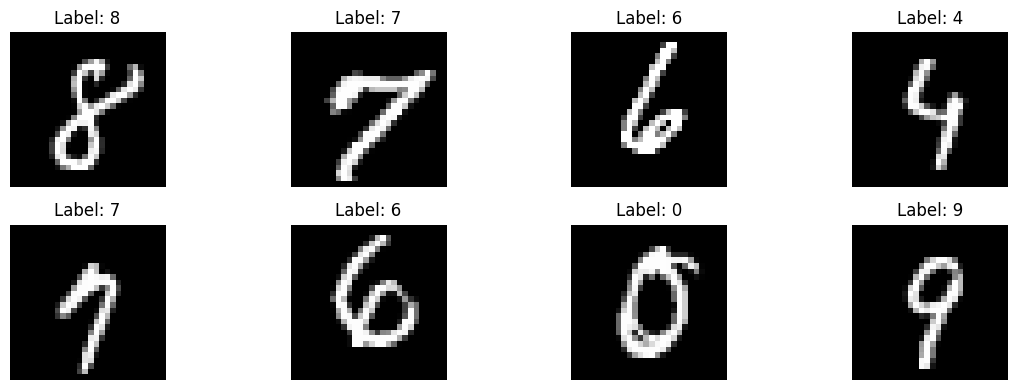

In [5]:
# Function to unnormalize image for display
def imshow(img, label=None):
    img = img / 2 + 0.5   # reverse normalization
    npimg = img.numpy()
    plt.imshow(np.squeeze(npimg), cmap="gray")
    if label is not None:
        plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

# Show a few sample images
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = images[i] / 2 + 0.5
    plt.imshow(np.squeeze(img.numpy()), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Understand image shape

Each image has shape:

**[channels, height, width] = [1, 28, 28]**

Here:

- `1` means grayscale image
- `28` is image height
- `28` is image width

In [6]:
print("Shape of one batch of images:", images.shape)
print("Shape of one image:", images[0].shape)

Shape of one batch of images: torch.Size([64, 1, 28, 28])
Shape of one image: torch.Size([1, 28, 28])


## 10. Build a simple CNN model

We will use:

- **Conv2d** → to extract features  
- **ReLU** → activation  
- **MaxPool2d** → reduce size  
- **Linear layer** → final classification  

### Architecture

Input image: **1 × 28 × 28**

After first convolution:
- output becomes **16 × 28 × 28**

After first max pooling:
- output becomes **16 × 14 × 14**

After second convolution:
- output becomes **32 × 14 × 14**

After second max pooling:
- output becomes **32 × 7 × 7**

Flatten:
- `32 × 7 × 7 = 1568`

Then fully connected layers:
- `1568 → 128 → 10`

In [7]:
# Define CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),  # 1x28x28 -> 16x28x28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                                 # 16x28x28 -> 16x14x14

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),  # 16x14x14 -> 32x14x14
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                                  # 32x14x14 -> 32x7x7
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Create model
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 11. Why do we not use Softmax in the last layer?

The last layer gives **raw scores**, also called **logits**.

We are using:

```python
nn.CrossEntropyLoss()
```

This loss function already applies the correct internal operation for multi-class classification.

So we keep the last layer as:

```python
nn.Linear(128, 10)
```

## 12. Define loss function and optimizer

### Loss function
For multi-class classification, we use:

**CrossEntropyLoss**

### Optimizer
We use:

**Adam**

because it is easy and works well for beginners.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 13. Training function

During training, the model learns by:

1. making predictions  
2. comparing predictions with true labels  
3. calculating loss  
4. updating weights using backpropagation

In [9]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=5):
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            # Statistics
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

    return train_losses, train_accuracies

## 14. Train the CNN

For Colab, 5 epochs is a good starting point.

You can later increase epochs for better accuracy.

In [10]:
epochs = 5
train_losses, train_accuracies = train_model(
    model, train_loader, criterion, optimizer, device, epochs=epochs
)

Epoch [1/5] - Loss: 0.1900 - Accuracy: 94.34%
Epoch [2/5] - Loss: 0.0528 - Accuracy: 98.40%
Epoch [3/5] - Loss: 0.0359 - Accuracy: 98.88%
Epoch [4/5] - Loss: 0.0266 - Accuracy: 99.19%
Epoch [5/5] - Loss: 0.0208 - Accuracy: 99.33%


## 15. Visualize training loss

A good sign is when the loss decreases over epochs.

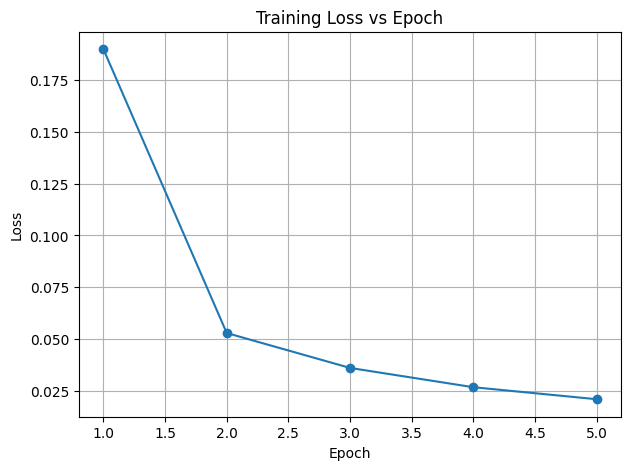

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()

## 16. Visualize training accuracy

A good sign is when accuracy increases with epochs.

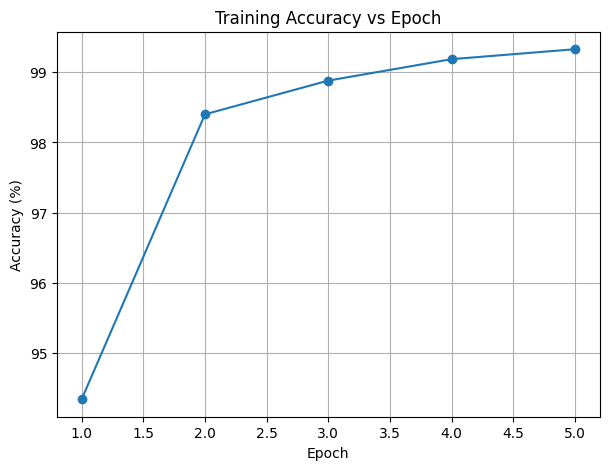

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Epoch")
plt.grid(True)
plt.show()

## 17. Evaluate the model on test data

Now we test the model on **unseen images**.

This tells us how well the model generalizes.

In [13]:
def evaluate_model(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(all_labels), np.array(all_predictions)

test_accuracy, true_labels, predicted_labels = evaluate_model(model, test_loader, device)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 98.99%


## 18. Classification report

This shows precision, recall, and F1-score for each digit class.

In [14]:
print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       1.00      0.97      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 19. Confusion matrix

A confusion matrix helps us see:

- which digits are predicted correctly
- which digits are confused with other digits

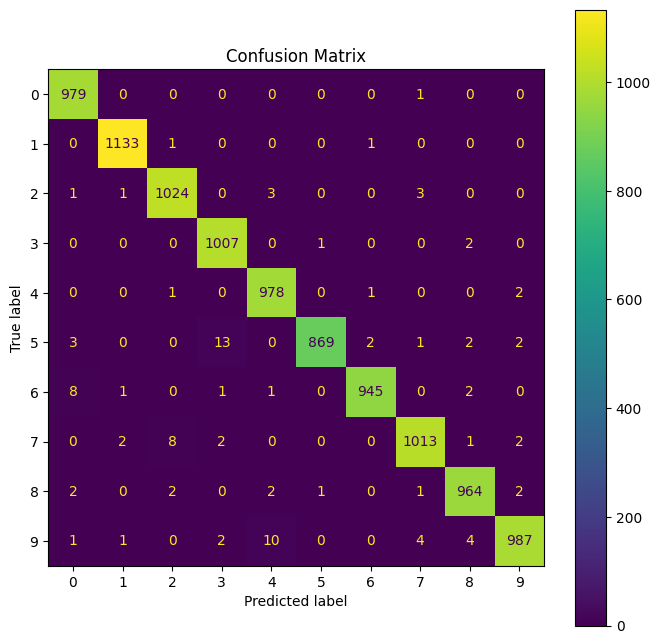

In [15]:
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

## 20. Show some predictions

Let us visualize some test images along with:

- true label
- predicted label

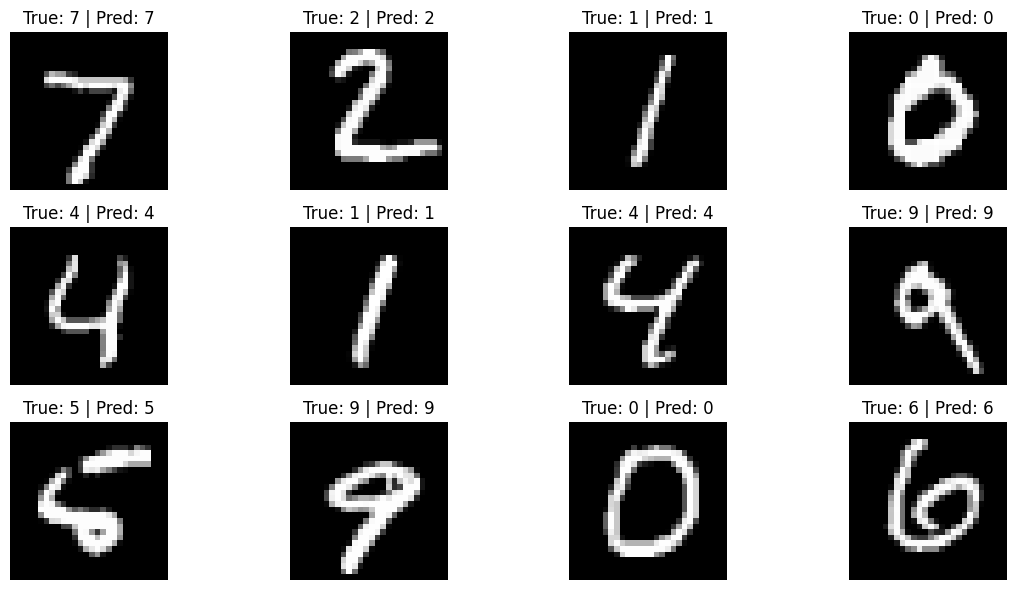

In [16]:
# Get a batch of test data
test_images, test_labels = next(iter(test_loader))
test_images_device = test_images.to(device)

# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(test_images_device)
    _, preds = torch.max(outputs, 1)

# Move predictions back to CPU
preds = preds.cpu()

# Plot sample predictions
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    img = test_images[i] / 2 + 0.5
    plt.imshow(np.squeeze(img.numpy()), cmap="gray")
    plt.title(f"True: {test_labels[i].item()} | Pred: {preds[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 21. Visualize feature maps from the first convolution layer

This is optional, but very useful for understanding what CNN learns.

Feature maps show how the network responds to strokes, edges, and patterns in the image.

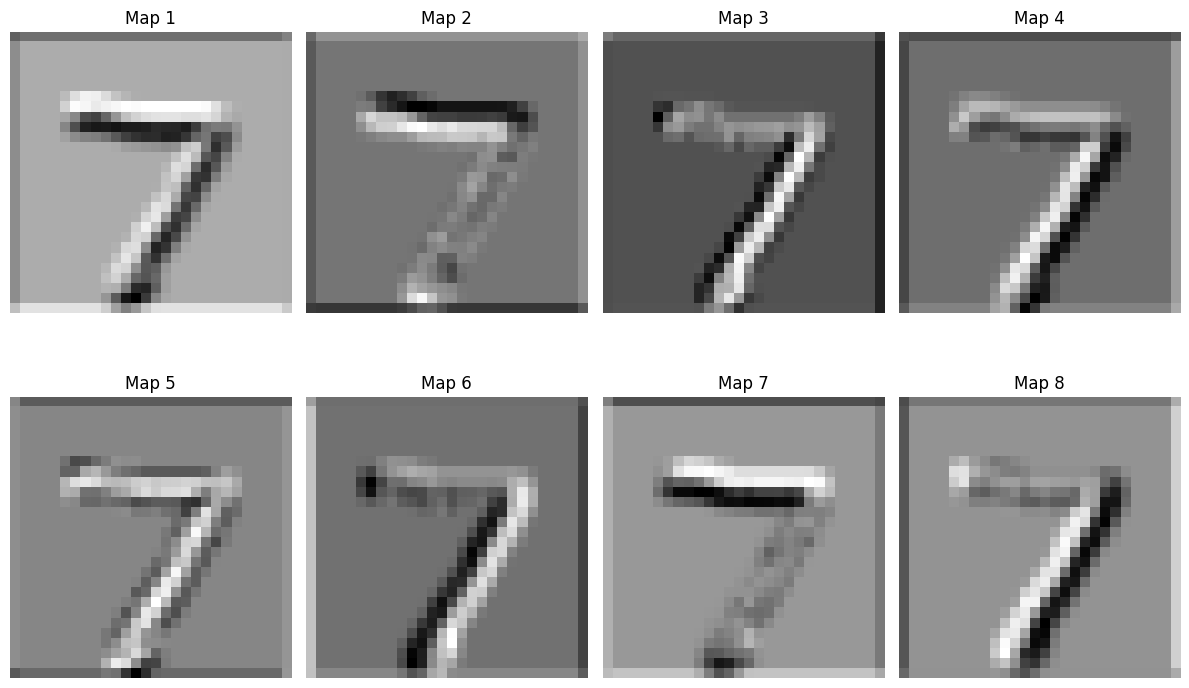

In [17]:
# Visualize feature maps from first convolutional layer
sample_image = test_images[0].unsqueeze(0).to(device)

first_conv = model.conv_layers[0]
with torch.no_grad():
    feature_maps = first_conv(sample_image)

feature_maps = feature_maps.cpu().squeeze(0)

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.title(f"Map {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 22. Predict a single image

This cell shows how to run inference on one image.

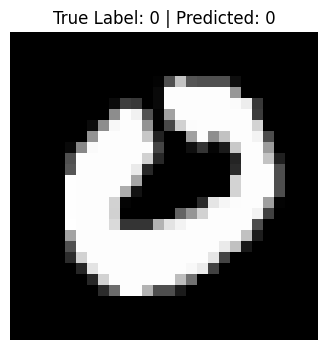

In [18]:
index = 25  # change this value to test different images

image, label = test_dataset[index]

model.eval()
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    prediction = torch.argmax(output, dim=1).item()

plt.figure(figsize=(4, 4))
img_show = image / 2 + 0.5
plt.imshow(np.squeeze(img_show.numpy()), cmap="gray")
plt.title(f"True Label: {label} | Predicted: {prediction}")
plt.axis("off")
plt.show()

## 23. Save the trained model

This is useful if you want to reuse the model later without retraining.

In [19]:
torch.save(model.state_dict(), "mnist_cnn_model.pth")
print("Model saved as mnist_cnn_model.pth")

Model saved as mnist_cnn_model.pth


## 24. Summary of what we built

In this notebook, we:

- loaded the MNIST handwritten digit dataset
- visualized sample images
- built a simple CNN in PyTorch
- trained it on handwritten digits
- evaluated its performance
- displayed predictions and confusion matrix

This is a complete beginner-friendly example of **handwritten digit detection using CNN**.

## 25. Exercises for students

You can now try these improvements:

1. increase epochs from 5 to 10  
2. add one more convolution layer  
3. add dropout for regularization  
4. compare CNN with a simple ANN  
5. test different batch sizes  
6. try your own handwritten digit image after preprocessing

## 26. Final note for Google Colab users

This notebook is ready to run in Colab.

### Recommended steps
1. Upload this notebook to Colab  
2. Enable GPU from runtime settings  
3. Run all cells from top to bottom  

If MNIST downloads successfully, the model should train without any extra dataset preparation.